# Лабораторная работа №3

**Тема:** эволюционная программа для решения задачи искусственного муравья.

Цель — подобрать конечный автомат, который управляет муравьем на поле `32 x 32` и максимизирует количество собранной еды.

## Идея решения

Особь в популяции — это конечный автомат. Автомат имеет фиксированное число состояний. Для каждой пары «состояние + входной сигнал» хранится действие и следующее состояние.

Входные сигналы:

- впереди еда;
- впереди препятствие или граница;
- впереди пустая клетка.

Действия:

- идти вперед;
- идти назад;
- повернуть налево;
- повернуть направо.

Если муравей заходит на клетку с едой, еда автоматически считается собранной. Действие «назад» добавлено отдельно, чтобы автомат мог отходить от тупиков и препятствий, а не только поворачиваться на месте.


In [12]:
import copy
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


GRID_SIZE = 32
MAX_STEPS = 1500
NUM_STATES = 10
NUM_INPUTS = 3
NUM_ACTIONS = 4
POPULATION_SIZE = 90
GENERATIONS = 90
MUTATION_RATE = 0.045
ELITE_COUNT = 2
TOURNAMENT_SIZE = 5
RUN_COUNT = 20
RANDOM_SEED = 137
OBSTACLE_DENSITY = 0.12
FOOD_CLUSTER_COUNT = 21
FOOD_CLUSTER_RADIUS = 3
FOOD_CLUSTER_PROBABILITY = 0.46

EMPTY = 0
OBSTACLE = 1
FOOD = 2

ACTIONS = ["Вперед", "Назад", "Налево", "Направо"]
INPUTS = ["Еда впереди", "Препятствие впереди", "Пусто впереди"]

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


## Генерация поля

Поле генерируется так же, как в сданном примере: часть клеток занята препятствиями, а еда размещается кластерами. Такое поле лучше показывает работу муравья, потому что еда образует дорожки и области скопления.

In [13]:
def generate_grid() -> np.ndarray:
    """Создает поле с препятствиями и кластерами еды."""
    grid = np.zeros((GRID_SIZE, GRID_SIZE), dtype=int)

    obstacle_count = int(GRID_SIZE**2 * OBSTACLE_DENSITY)
    for _ in range(obstacle_count):
        row = random.randint(0, GRID_SIZE - 1)
        col = random.randint(0, GRID_SIZE - 1)
        if (row, col) != (0, 0):
            grid[row, col] = OBSTACLE

    for _ in range(FOOD_CLUSTER_COUNT):
        center_row = random.randint(FOOD_CLUSTER_RADIUS, GRID_SIZE - FOOD_CLUSTER_RADIUS - 1)
        center_col = random.randint(FOOD_CLUSTER_RADIUS, GRID_SIZE - FOOD_CLUSTER_RADIUS - 1)
        for d_row in range(-FOOD_CLUSTER_RADIUS, FOOD_CLUSTER_RADIUS + 1):
            for d_col in range(-FOOD_CLUSTER_RADIUS, FOOD_CLUSTER_RADIUS + 1):
                row = center_row + d_row
                col = center_col + d_col
                if (
                    0 <= row < GRID_SIZE
                    and 0 <= col < GRID_SIZE
                    and grid[row, col] == EMPTY
                    and random.random() < FOOD_CLUSTER_PROBABILITY
                ):
                    grid[row, col] = FOOD

    grid[0, 0] = EMPTY
    return grid


original_grid = generate_grid()
total_food = int(np.count_nonzero(original_grid == FOOD))
print(f"Всего еды: {total_food}")


Всего еды: 339


## Кодирование конечного автомата

Геном — это список чисел. Каждое число кодирует пару:

```text
действие, следующее состояние
```

Для автомата из `10` состояний и `3` входных сигналов длина генома равна `30`. Значение каждого гена выбирает одно из `4` действий и следующее состояние автомата.


In [14]:
def create_random_genome() -> list[int]:
    """Создает случайный геном конечного автомата."""
    max_gene_value = (NUM_ACTIONS - 1) * NUM_STATES + (NUM_STATES - 1)
    return [random.randint(0, max_gene_value) for _ in range(NUM_STATES * NUM_INPUTS)]


def decode_genome(genome: list[int]) -> list[list[tuple[int, int]]]:
    """Преобразует геном в таблицу переходов автомата."""
    fsm = []
    for state in range(NUM_STATES):
        row = []
        for input_type in range(NUM_INPUTS):
            value = genome[state * NUM_INPUTS + input_type]
            action = value // NUM_STATES
            next_state = value % NUM_STATES
            row.append((action, next_state))
        fsm.append(row)
    return fsm

## Моделирование муравья

Муравей начинает в клетке `(0, 0)` и смотрит вверх. На каждом шаге он смотрит на клетку перед собой, автомат выбирает действие, затем муравей выполняет это действие. Доступны движение вперед, движение назад, поворот налево и поворот направо. Если муравей заходит на еду, она исчезает, а фитнес увеличивается.


In [15]:
def simulate_ant(genome: list[int], grid: np.ndarray) -> tuple[int, list[tuple[int, int]]]:
    """Запускает муравья на поле и возвращает число еды и путь."""
    fsm = decode_genome(genome)
    row, col = 0, 0
    direction = 0
    state = 0
    path = [(row, col)]
    food_collected = 0
    moves = [(-1, 0), (0, 1), (1, 0), (0, -1)]

    if grid[row, col] == FOOD:
        grid[row, col] = EMPTY
        food_collected += 1

    for _ in range(MAX_STEPS):
        front_row = row + moves[direction][0]
        front_col = col + moves[direction][1]

        if (
            front_row < 0
            or front_row >= GRID_SIZE
            or front_col < 0
            or front_col >= GRID_SIZE
            or grid[front_row, front_col] == OBSTACLE
        ):
            sensor = 1
        elif grid[front_row, front_col] == FOOD:
            sensor = 0
        else:
            sensor = 2

        action, next_state = fsm[state][sensor]
        state = next_state

        if action in (0, 1):
            move_direction = direction if action == 0 else (direction + 2) % 4
            target_row = row + moves[move_direction][0]
            target_col = col + moves[move_direction][1]

            if 0 <= target_row < GRID_SIZE and 0 <= target_col < GRID_SIZE and grid[target_row, target_col] != OBSTACLE:
                row, col = target_row, target_col
                path.append((row, col))
                if grid[row, col] == FOOD:
                    grid[row, col] = EMPTY
                    food_collected += 1
        elif action == 2:
            direction = (direction - 1) % 4
        elif action == 3:
            direction = (direction + 1) % 4

    return food_collected, path


## Разнообразие популяции

Разнообразие считается как среднее нормированное расстояние Хэмминга между геномами. Если значение близко к `1`, геномы сильно различаются; если близко к `0`, популяция стала похожей.

In [16]:
def calculate_diversity(population: list[list[int]]) -> float:
    """Считает среднее генетическое различие между особями."""
    if len(population) < 2:
        return 0.0

    total_difference = 0.0
    comparisons = 0
    genome_length = len(population[0])

    for i in range(len(population)):
        for j in range(i + 1, len(population)):
            difference = sum(a != b for a, b in zip(population[i], population[j]))
            total_difference += difference / genome_length
            comparisons += 1

    return total_difference / comparisons

## Эволюционный алгоритм

Используются элитизм, турнирный отбор, одноточечное скрещивание и мутация генов. Фитнес — количество собранной еды. Мутация меняет правила переходов автомата: действие и следующее состояние для отдельных входных ситуаций.


In [17]:
def run_evolution(fixed_grid: np.ndarray) -> dict[str, object]:
    """Запускает один прогон эволюционного алгоритма."""
    population = [create_random_genome() for _ in range(POPULATION_SIZE)]
    best_ever_genome = None
    best_ever_path = []
    best_ever_fitness = -1
    fitness_history = []
    avg_fitness_history = []
    diversity_history = []

    for generation in range(GENERATIONS):
        results = []
        for genome in population:
            grid_copy = fixed_grid.copy()
            fitness, path = simulate_ant(genome, grid_copy)
            results.append((fitness, path, genome))

        results.sort(key=lambda item: item[0], reverse=True)
        best_fitness, best_path, best_genome = results[0]
        avg_fitness = float(np.mean([item[0] for item in results]))

        if best_fitness > best_ever_fitness:
            best_ever_fitness = best_fitness
            best_ever_path = best_path.copy()
            best_ever_genome = best_genome.copy()

        fitness_history.append(best_fitness)
        avg_fitness_history.append(avg_fitness)
        diversity_history.append(calculate_diversity([item[2] for item in results]))

        new_population = [copy.deepcopy(item[2]) for item in results[:ELITE_COUNT]]

        while len(new_population) < POPULATION_SIZE:
            contenders = random.sample(results, TOURNAMENT_SIZE)
            parent_a = max(contenders, key=lambda item: item[0])[2]

            contenders = random.sample(results, TOURNAMENT_SIZE)
            parent_b = max(contenders, key=lambda item: item[0])[2]

            child = parent_a.copy()
            crossover_point = random.randint(0, len(child) - 1)
            child[crossover_point:] = parent_b[crossover_point:]

            max_gene_value = (NUM_ACTIONS - 1) * NUM_STATES + (NUM_STATES - 1)
            for gene_index in range(len(child)):
                if random.random() < MUTATION_RATE:
                    child[gene_index] = random.randint(0, max_gene_value)

            new_population.append(child)

        population = new_population

    return {
        "genome": best_ever_genome,
        "path": best_ever_path,
        "fitness": best_ever_fitness,
        "fitness_history": fitness_history,
        "avg_fitness_history": avg_fitness_history,
        "diversity_history": diversity_history,
    }

## Запуск 20 прогонов

Несколько прогонов нужны, чтобы оценить устойчивость алгоритма. На графиках ниже линия показывает среднее, а заливка — `±1 sigma`.

In [18]:
all_results = []

for run in range(RUN_COUNT):
    result = run_evolution(original_grid)
    result["run"] = run + 1
    all_results.append(result)
    print(f"Прогон {run + 1:2d}/{RUN_COUNT}: собрано {result['fitness']:3d}/{total_food}")

fitnesses = [result["fitness"] for result in all_results]
best_run = max(all_results, key=lambda item: item["fitness"])

print()
print(f"Лучший результат: {best_run['fitness']} из {total_food} еды, прогон #{best_run['run']}")
print(f"Среднее по прогонам: {np.mean(fitnesses):.2f} ± {np.std(fitnesses):.2f}")

Прогон  1/20: собрано 190/339
Прогон  2/20: собрано 237/339
Прогон  3/20: собрано 245/339
Прогон  4/20: собрано 224/339
Прогон  5/20: собрано 226/339
Прогон  6/20: собрано 240/339
Прогон  7/20: собрано 250/339
Прогон  8/20: собрано 247/339
Прогон  9/20: собрано 252/339
Прогон 10/20: собрано 253/339
Прогон 11/20: собрано 209/339
Прогон 12/20: собрано 245/339
Прогон 13/20: собрано 257/339
Прогон 14/20: собрано 214/339
Прогон 15/20: собрано 214/339
Прогон 16/20: собрано 204/339
Прогон 17/20: собрано 186/339
Прогон 18/20: собрано 258/339
Прогон 19/20: собрано 264/339
Прогон 20/20: собрано 248/339

Лучший результат: 264 из 339 еды, прогон #19
Среднее по прогонам: 233.15 ± 22.71


## Таблица переходов лучшего автомата

In [19]:
def genome_to_table(genome: list[int]) -> list[list[str]]:
    """Преобразует геном лучшего автомата в таблицу переходов."""
    fsm = decode_genome(genome)
    table = []
    for state_index, row in enumerate(fsm):
        table_row = [f"S{state_index}"]
        for action, next_state in row:
            table_row.append(f"{ACTIONS[action]} -> S{next_state}")
        table.append(table_row)
    return table


headers = ["Состояние"] + INPUTS
best_table = genome_to_table(best_run["genome"])

print(" | ".join(headers))
print("-" * 90)
for row in best_table:
    print(" | ".join(row))

Состояние | Еда впереди | Препятствие впереди | Пусто впереди
------------------------------------------------------------------------------------------
S0 | Вперед -> S9 | Налево -> S0 | Налево -> S3
S1 | Направо -> S9 | Налево -> S9 | Налево -> S4
S2 | Направо -> S3 | Направо -> S0 | Налево -> S9
S3 | Вперед -> S6 | Направо -> S4 | Вперед -> S3
S4 | Вперед -> S0 | Налево -> S5 | Вперед -> S0
S5 | Налево -> S7 | Назад -> S2 | Назад -> S0
S6 | Налево -> S2 | Назад -> S1 | Направо -> S9
S7 | Направо -> S6 | Направо -> S0 | Вперед -> S1
S8 | Назад -> S7 | Направо -> S9 | Налево -> S1
S9 | Вперед -> S4 | Назад -> S4 | Назад -> S7


## Визуализация лучшего маршрута

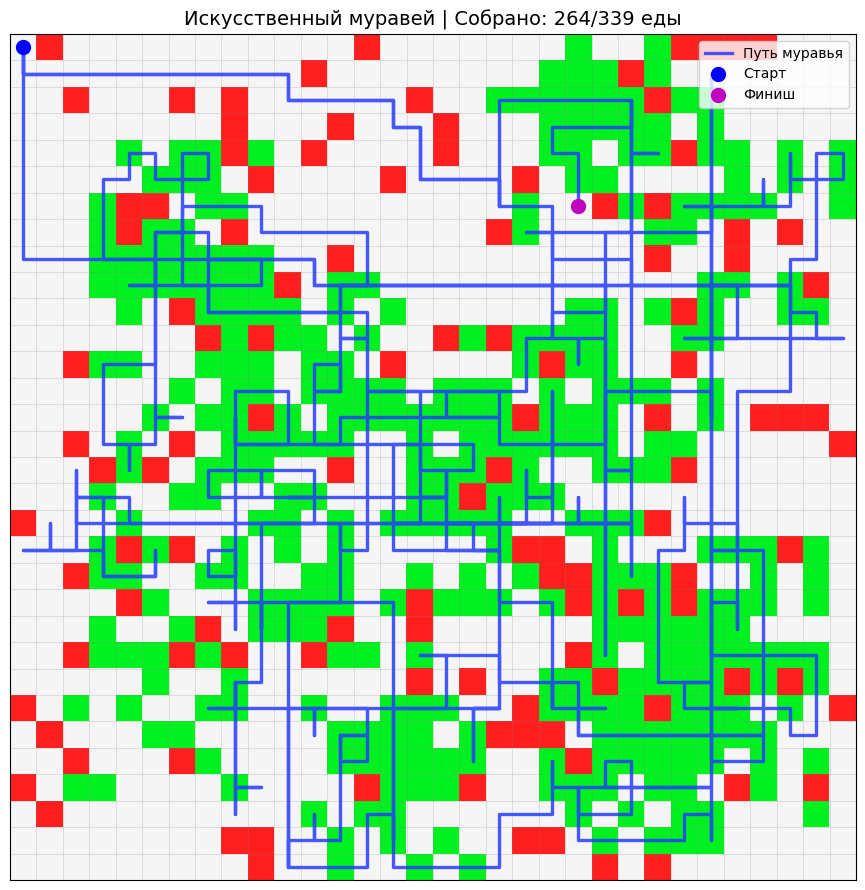

In [20]:
def visualize_path(grid: np.ndarray, path: list[tuple[int, int]], food_collected: int, total_food: int) -> None:
    """Отображает поле, еду, препятствия и путь муравья."""
    fig, ax = plt.subplots(figsize=(9, 9))
    cmap = plt.cm.colors.ListedColormap(["#f5f5f5", "#ff1f1f", "#00f020"])
    ax.imshow(grid, cmap=cmap, interpolation="nearest", vmin=0, vmax=2)

    rows, cols = zip(*path)
    ax.plot(cols, rows, color="#263cff", linewidth=2.4, alpha=0.85, label="Путь муравья")
    ax.plot(cols[0], rows[0], "bo", markersize=10, label="Старт")
    ax.plot(cols[-1], rows[-1], "mo", markersize=10, label="Финиш")

    ax.set_title(f"Искусственный муравей | Собрано: {food_collected}/{total_food} еды", fontsize=14)
    ax.set_xticks(np.arange(-0.5, GRID_SIZE, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, GRID_SIZE, 1), minor=True)
    ax.grid(which="minor", color="gray", linestyle="-", linewidth=0.5, alpha=0.3)
    ax.tick_params(which="both", bottom=False, left=False, labelbottom=False, labelleft=False)
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


visualize_path(original_grid, best_run["path"], best_run["fitness"], total_food)

## Сходимость и разнообразие

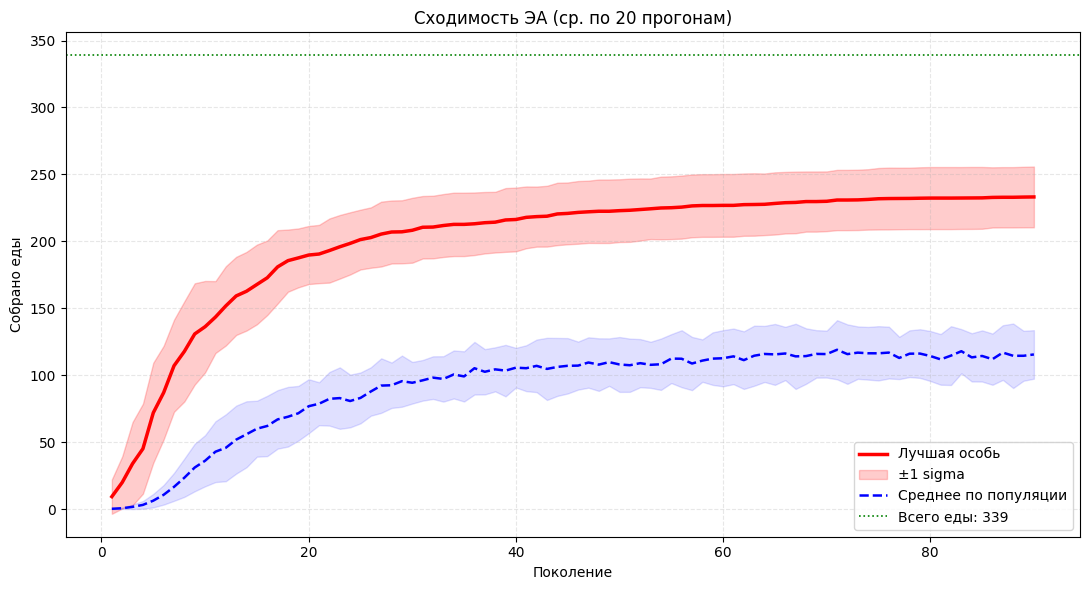

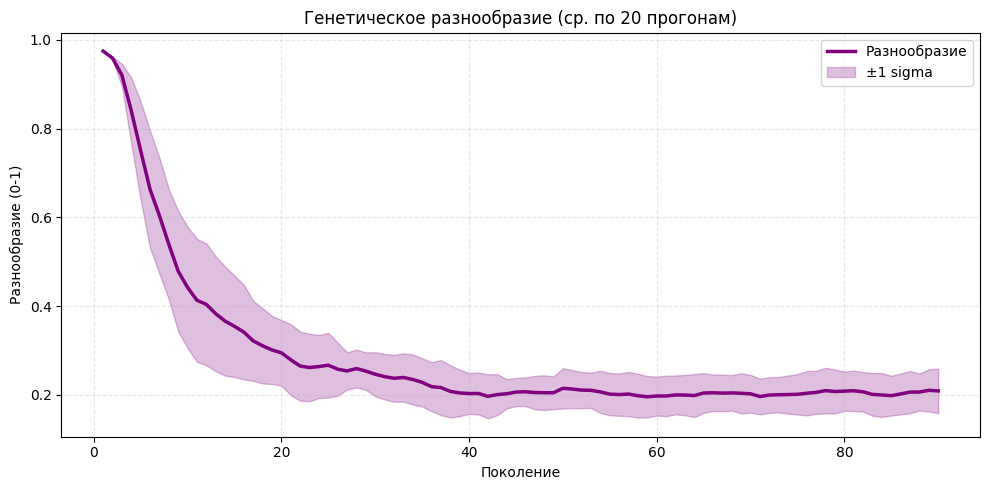

In [21]:
def plot_convergence_aggregated(all_results: list[dict[str, object]], total_food: int) -> None:
    """Строит средние графики сходимости по всем прогонам."""
    best_curves = np.array([result["fitness_history"] for result in all_results])
    avg_curves = np.array([result["avg_fitness_history"] for result in all_results])
    generations = np.arange(1, GENERATIONS + 1)

    best_mean = np.mean(best_curves, axis=0)
    best_std = np.std(best_curves, axis=0)
    avg_mean = np.mean(avg_curves, axis=0)
    avg_std = np.std(avg_curves, axis=0)

    plt.figure(figsize=(11, 6))
    plt.plot(generations, best_mean, color="red", linewidth=2.5, label="Лучшая особь")
    plt.fill_between(generations, best_mean - best_std, best_mean + best_std, color="red", alpha=0.2, label="±1 sigma")
    plt.plot(generations, avg_mean, color="blue", linestyle="--", linewidth=1.8, label="Среднее по популяции")
    plt.fill_between(generations, avg_mean - avg_std, avg_mean + avg_std, color="blue", alpha=0.12)
    plt.axhline(total_food, color="green", linestyle=":", linewidth=1.2, label=f"Всего еды: {total_food}")
    plt.xlabel("Поколение")
    plt.ylabel("Собрано еды")
    plt.title(f"Сходимость ЭА (ср. по {RUN_COUNT} прогонам)")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3, linestyle="--")
    plt.tight_layout()
    plt.show()


def plot_diversity_aggregated(all_results: list[dict[str, object]]) -> None:
    """Строит средний график генетического разнообразия."""
    diversity_curves = np.array([result["diversity_history"] for result in all_results])
    generations = np.arange(1, GENERATIONS + 1)

    diversity_mean = np.mean(diversity_curves, axis=0)
    diversity_std = np.std(diversity_curves, axis=0)

    plt.figure(figsize=(10, 5))
    plt.plot(generations, diversity_mean, color="purple", linewidth=2.5, label="Разнообразие")
    plt.fill_between(
        generations,
        np.clip(diversity_mean - diversity_std, 0, 1),
        np.clip(diversity_mean + diversity_std, 0, 1),
        color="purple",
        alpha=0.25,
        label="±1 sigma",
    )
    plt.xlabel("Поколение")
    plt.ylabel("Разнообразие (0-1)")
    plt.title(f"Генетическое разнообразие (ср. по {RUN_COUNT} прогонам)")
    plt.legend()
    plt.grid(alpha=0.3, linestyle="--")
    plt.tight_layout()
    plt.show()


plot_convergence_aggregated(all_results, total_food)
plot_diversity_aggregated(all_results)

## Сохранение результатов

In [22]:
notebook_root = Path.cwd()
lab_dir = notebook_root / "EVAL" / "lab_3" if (notebook_root / "EVAL" / "lab_3").exists() else notebook_root
output_dir = lab_dir / "results"
output_dir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(9, 9))
cmap = plt.cm.colors.ListedColormap(["#f5f5f5", "#ff1f1f", "#00f020"])
ax.imshow(original_grid, cmap=cmap, interpolation="nearest", vmin=0, vmax=2)
rows, cols = zip(*best_run["path"])
ax.plot(cols, rows, color="#263cff", linewidth=2.4, alpha=0.85, label="Путь муравья")
ax.plot(cols[0], rows[0], "bo", markersize=10, label="Старт")
ax.plot(cols[-1], rows[-1], "mo", markersize=10, label="Финиш")
ax.set_title(f"Искусственный муравей | Собрано: {best_run['fitness']}/{total_food} еды", fontsize=14)
ax.set_xticks(np.arange(-0.5, GRID_SIZE, 1), minor=True)
ax.set_yticks(np.arange(-0.5, GRID_SIZE, 1), minor=True)
ax.grid(which="minor", color="gray", linestyle="-", linewidth=0.5, alpha=0.3)
ax.tick_params(which="both", bottom=False, left=False, labelbottom=False, labelleft=False)
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig(output_dir / "ant_path.png", dpi=160)
plt.close()

best_curves = np.array([result["fitness_history"] for result in all_results])
avg_curves = np.array([result["avg_fitness_history"] for result in all_results])
diversity_curves = np.array([result["diversity_history"] for result in all_results])
generations = np.arange(1, GENERATIONS + 1)

best_mean = np.mean(best_curves, axis=0)
best_std = np.std(best_curves, axis=0)
avg_mean = np.mean(avg_curves, axis=0)
avg_std = np.std(avg_curves, axis=0)
diversity_mean = np.mean(diversity_curves, axis=0)
diversity_std = np.std(diversity_curves, axis=0)

plt.figure(figsize=(11, 6))
plt.plot(generations, best_mean, color="red", linewidth=2.5, label="Лучшая особь")
plt.fill_between(generations, best_mean - best_std, best_mean + best_std, color="red", alpha=0.2, label="±1 sigma")
plt.plot(generations, avg_mean, color="blue", linestyle="--", linewidth=1.8, label="Среднее по популяции")
plt.fill_between(generations, avg_mean - avg_std, avg_mean + avg_std, color="blue", alpha=0.12)
plt.axhline(total_food, color="green", linestyle=":", linewidth=1.2, label=f"Всего еды: {total_food}")
plt.xlabel("Поколение")
plt.ylabel("Собрано еды")
plt.title(f"Сходимость ЭА (ср. по {RUN_COUNT} прогонам)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.savefig(output_dir / "convergence_sigma.png", dpi=160)
plt.close()

plt.figure(figsize=(10, 5))
plt.plot(generations, diversity_mean, color="purple", linewidth=2.5, label="Разнообразие")
plt.fill_between(
    generations,
    np.clip(diversity_mean - diversity_std, 0, 1),
    np.clip(diversity_mean + diversity_std, 0, 1),
    color="purple",
    alpha=0.25,
    label="±1 sigma",
)
plt.xlabel("Поколение")
plt.ylabel("Разнообразие (0-1)")
plt.title(f"Генетическое разнообразие (ср. по {RUN_COUNT} прогонам)")
plt.legend()
plt.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.savefig(output_dir / "diversity_sigma.png", dpi=160)
plt.close()

summary_lines = [
    "Лабораторная работа N3",
    "Тема: эволюционная программа для искусственного муравья",
    "",
    f"Размер поля: {GRID_SIZE} x {GRID_SIZE}",
    f"Всего еды на поле: {total_food}",
    f"Лучший результат: {best_run['fitness']}",
    f"Номер лучшего прогона: {best_run['run']}",
    f"Среднее по прогонам: {np.mean(fitnesses):.2f} ± {np.std(fitnesses):.2f}",
    f"Длина пути лучшего муравья: {len(best_run['path'])}",
    "",
    "Таблица переходов лучшего автомата:",
    " | ".join(headers),
]
summary_lines.extend(" | ".join(row) for row in best_table)
(output_dir / "summary.txt").write_text("\n".join(summary_lines), encoding="utf-8")
print(f"Результаты сохранены в: {output_dir.resolve()}")

Результаты сохранены в: C:\Users\motyn\Desktop\repositories\_OMSTU\EVAL\lab_3\results


## Анализ результатов

На графике сходимости видно, что качество лучших автоматов быстро растет на первых поколениях, а затем выходит на плато. Это означает, что популяция нашла устойчивые стратегии движения по скоплениям еды.

График разнообразия показывает снижение генетического разнообразия: сначала геномы сильно отличаются, затем отбор и элитизм закрепляют успешные таблицы переходов. Заливка `±1 sigma` показывает разброс между 20 независимыми прогонами.

## Вывод

В работе реализована эволюционная программа для задачи искусственного муравья. Конечный автомат кодируется геномом, эволюция выполняется через отбор, скрещивание, мутацию и элитизм. Итогом является лучший найденный автомат, его таблица переходов, путь муравья и графики качества и разнообразия по поколениям.